In [1]:
import shutil
shutil.unpack_archive('results.zip', '../results')

In [3]:
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras

os.makedirs('../results', exist_ok=True)

df_15min = pd.read_csv('/content/datos_procesados.csv', index_col='fecha', parse_dates=True)

# Cargar N-BEATS
best_overall_model = keras.models.load_model('../results/nbeats_trafico.keras')
with open('../results/nbeats_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('../results/nbeats_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)
best_input_length = metadata['best_input_length']

# Cargar Prophet
with open('../results/prophet_model.pkl', 'rb') as f:
    model_prophet = pickle.load(f)

print(f"N-BEATS input_length: {best_input_length}")

N-BEATS input_length: 24


In [4]:
from sklearn.preprocessing import MinMaxScaler

values = df_15min['body.counting'].values.reshape(-1, 1)
values_scaled = scaler.transform(values).flatten()

def create_sequences(data, input_length=24, forecast_length=4):
    X, y = [], []
    for i in range(len(data) - input_length - forecast_length + 1):
        X.append(data[i:i+input_length])
        y.append(data[i+input_length:i+input_length+forecast_length])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(values_scaled, input_length=best_input_length)
split = int(len(X_all) * 0.8)
X_best_val = X_all[split:]
y_best_val = y_all[split:]

# Prophet split
df_prophet = df_15min.reset_index().rename(columns={'fecha': 'ds', 'body.counting': 'y'})
split_p = int(len(df_prophet) * 0.8)
test_prophet = df_prophet[split_p:].reset_index(drop=True)

In [5]:
y_pred_scaled = best_overall_model.predict(X_best_val)
y_pred_nbeats = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1, 4).sum(axis=1)
y_real_nbeats = scaler.inverse_transform(y_best_val.reshape(-1, 1)).reshape(-1, 4).sum(axis=1)

fechas_nbeats = df_15min.index[best_input_length + split : best_input_length + split + len(y_best_val)]

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step


In [6]:
future = model_prophet.make_future_dataframe(periods=len(test_prophet), freq='15min')
forecast = model_prophet.predict(future)
forecast_test = forecast.tail(len(test_prophet)).reset_index(drop=True)
y_real_prophet = test_prophet['y'].values
y_pred_prophet = forecast_test['yhat'].values.clip(min=0)
fechas_prophet = pd.to_datetime(test_prophet['ds'].values)

In [7]:
def calcular_metricas(y_real, y_pred, nombre):
    mae  = np.mean(np.abs(y_real - y_pred))
    rmse = np.sqrt(np.mean((y_real - y_pred) ** 2))
    mape = np.mean(np.abs((y_real - y_pred) / (y_real + 1e-8))) * 100
    smape = np.mean(2 * np.abs(y_real - y_pred) / (np.abs(y_real) + np.abs(y_pred) + 1e-8)) * 100
    r2   = 1 - np.sum((y_real - y_pred)**2) / np.sum((y_real - np.mean(y_real))**2)
    print(f"\n{nombre}")
    print(f"  MAE:   {mae:.2f}")
    print(f"  RMSE:  {rmse:.2f}")
    print(f"  MAPE:  {mape:.2f}%")
    print(f"  sMAPE: {smape:.2f}%")
    print(f"  R²:    {r2:.4f}")
    return {'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'sMAPE': smape, 'R2': r2}

m1 = calcular_metricas(y_real_nbeats, y_pred_nbeats, 'N-BEATS')
m2 = calcular_metricas(y_real_prophet, y_pred_prophet, 'Prophet')

df_metricas = pd.DataFrame([m1, m2])
df_metricas.to_csv('../results/metricas.csv', index=False)
print("\nGuardado en ../results/metricas.csv")


N-BEATS
  MAE:   19.49
  RMSE:  26.17
  MAPE:  31.57%
  sMAPE: 28.22%
  R²:    0.2483

Prophet
  MAE:   9.52
  RMSE:  12.59
  MAPE:  100.84%
  sMAPE: 54.75%
  R²:    -0.0168

Guardado en ../results/metricas.csv


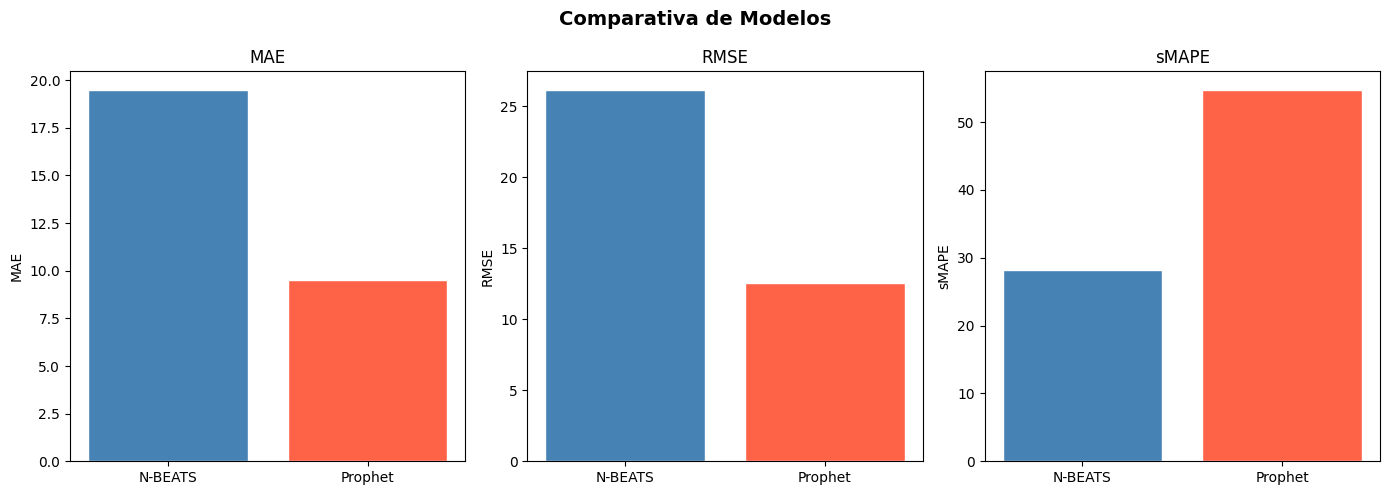

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Comparativa de Modelos', fontsize=14, fontweight='bold')

for i, metrica in enumerate(['MAE', 'RMSE', 'sMAPE']):
    axes[i].bar(df_metricas['Modelo'], df_metricas[metrica], color=['steelblue', 'tomato'], edgecolor='white')
    axes[i].set_title(metrica)
    axes[i].set_ylabel(metrica)

plt.tight_layout()
plt.savefig('../results/comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

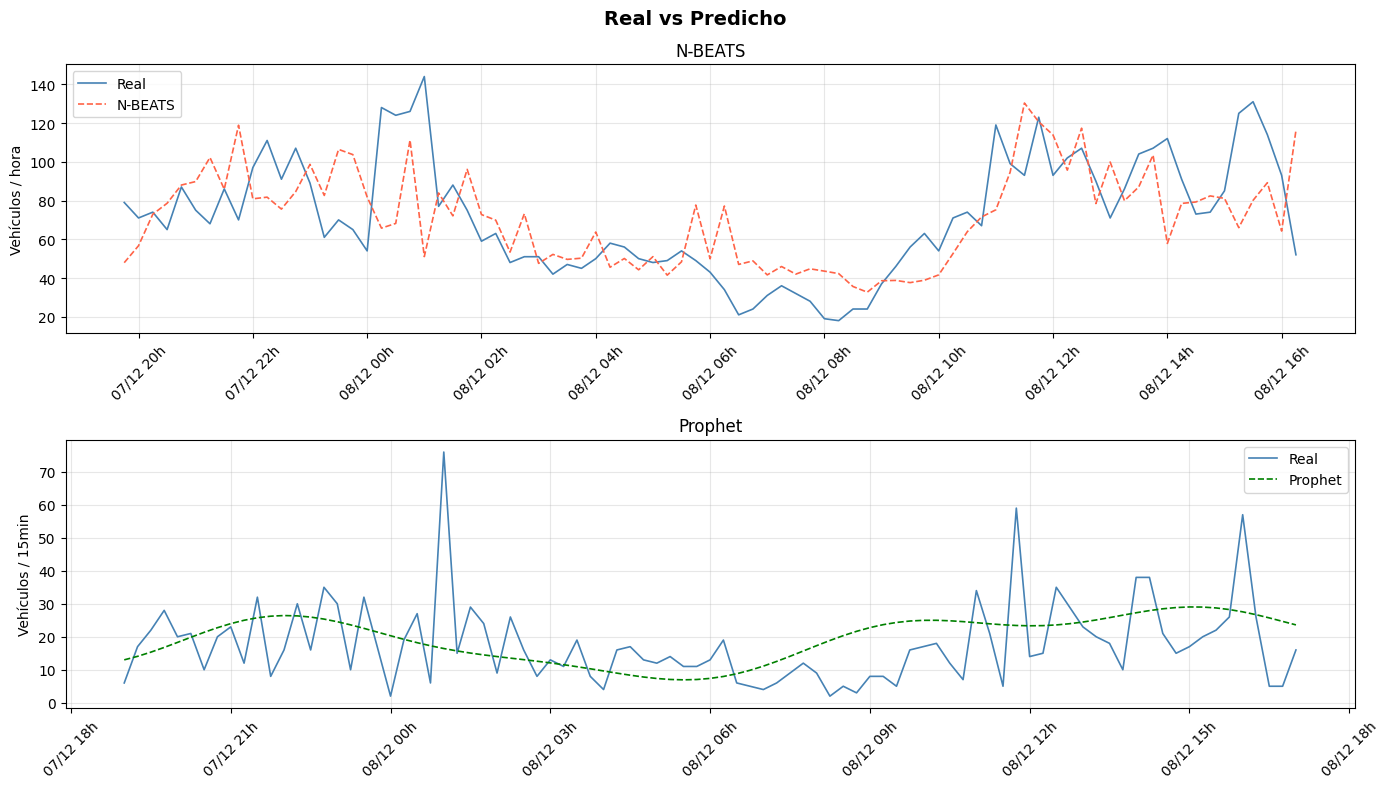

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Real vs Predicho', fontsize=14, fontweight='bold')

axes[0].plot(fechas_nbeats, y_real_nbeats, label='Real', color='steelblue', linewidth=1.2)
axes[0].plot(fechas_nbeats, y_pred_nbeats, label='N-BEATS', color='tomato', linewidth=1.2, linestyle='--')
axes[0].set_title('N-BEATS')
axes[0].set_ylabel('Vehículos / hora')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].plot(fechas_prophet, y_real_prophet, label='Real', color='steelblue', linewidth=1.2)
axes[1].plot(fechas_prophet, y_pred_prophet, label='Prophet', color='green', linewidth=1.2, linestyle='--')
axes[1].set_title('Prophet')
axes[1].set_ylabel('Vehículos / 15min')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../results/real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()

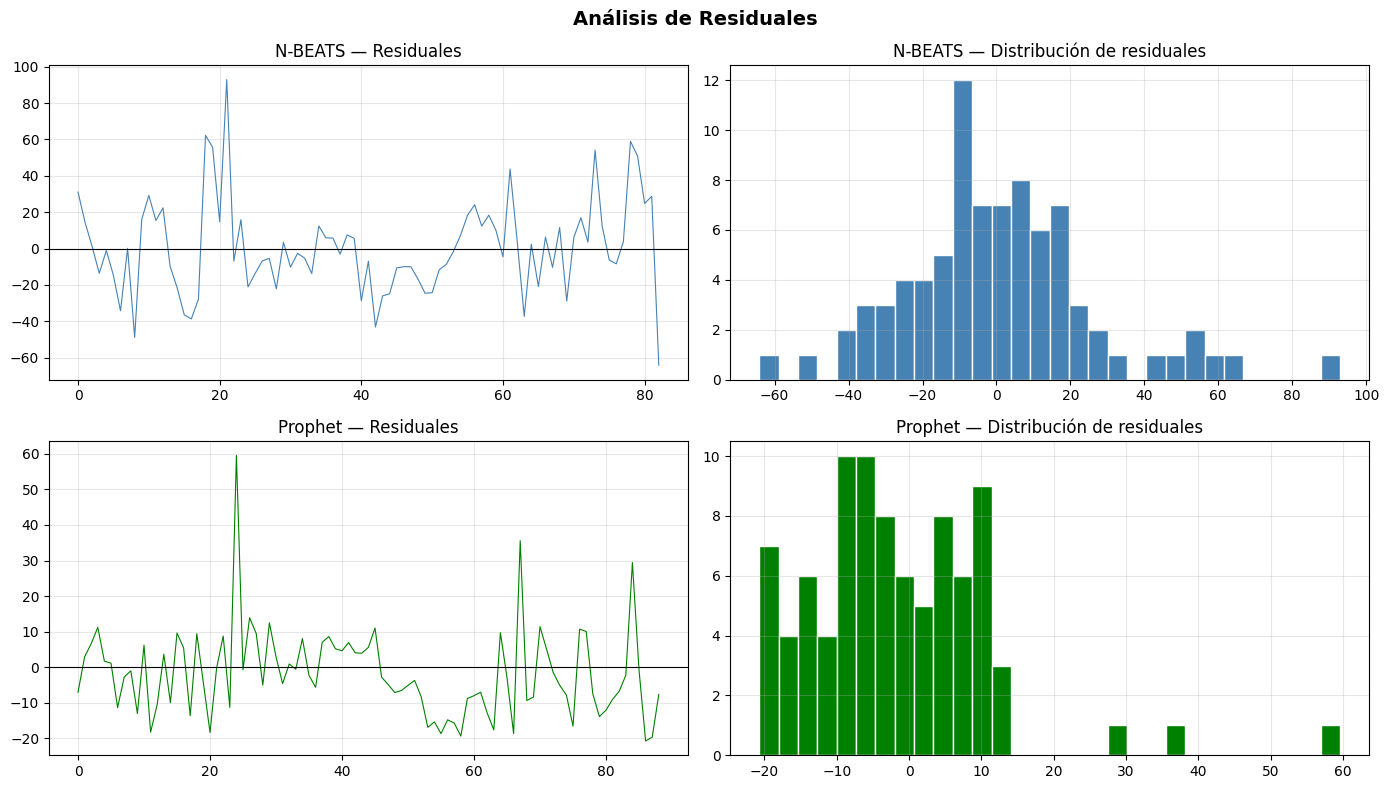

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Análisis de Residuales', fontsize=14, fontweight='bold')

residuales_nb = y_real_nbeats - y_pred_nbeats
residuales_pr = y_real_prophet - y_pred_prophet

# N-BEATS
axes[0,0].plot(residuales_nb, color='steelblue', linewidth=0.8)
axes[0,0].axhline(0, color='black', linewidth=0.8)
axes[0,0].set_title('N-BEATS — Residuales')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(residuales_nb, bins=30, color='steelblue', edgecolor='white')
axes[0,1].set_title('N-BEATS — Distribución de residuales')
axes[0,1].grid(True, alpha=0.3)

# Prophet
axes[1,0].plot(residuales_pr, color='green', linewidth=0.8)
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_title('Prophet — Residuales')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(residuales_pr, bins=30, color='green', edgecolor='white')
axes[1,1].set_title('Prophet — Distribución de residuales')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/residuales.png', dpi=150, bbox_inches='tight')
plt.show()